In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# 1. Load the California Housing dataset
housing = fetch_california_housing()

# Convert to Pandas DataFrame
df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
# The target variable is the median house value (in $100,000s)
df['Price'] = housing.target 

# --- Exploratory Data Analysis (EDA) ---

print("--- First 5 Rows ---")
display(df.head()) 

print("\n--- Dataset Info ---")
df.info()

print("\n--- Statistical Summary ---")
display(df.describe())

print("\n--- Missing Values ---")
display(df.isnull().sum())

--- First 5 Rows ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

--- Statistical Summary ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



--- Missing Values ---


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

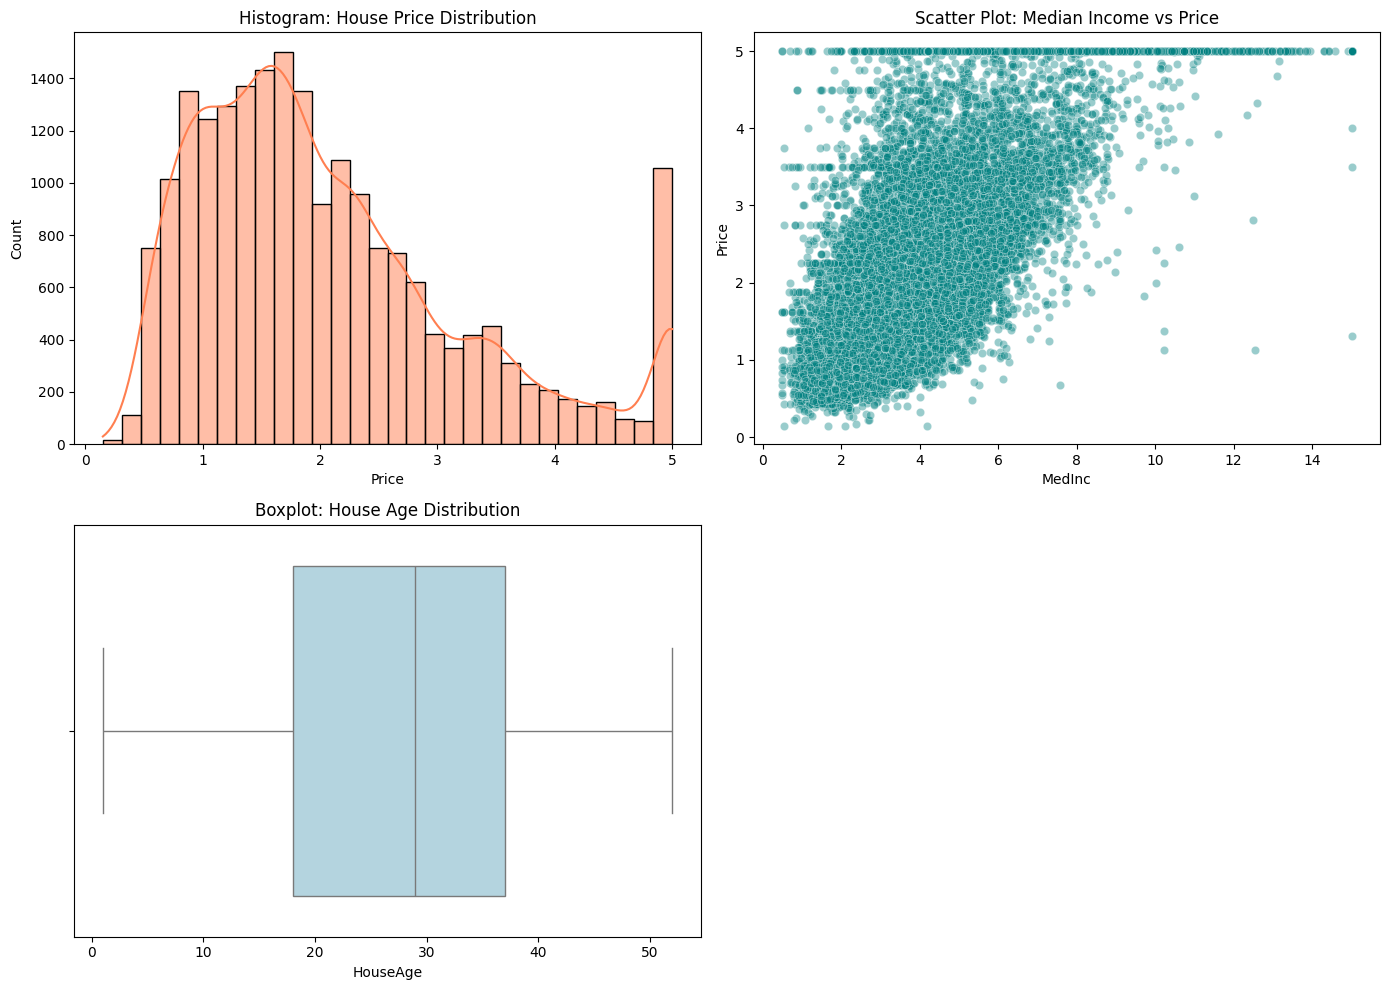


--- Pairplot (Subset of Features) ---


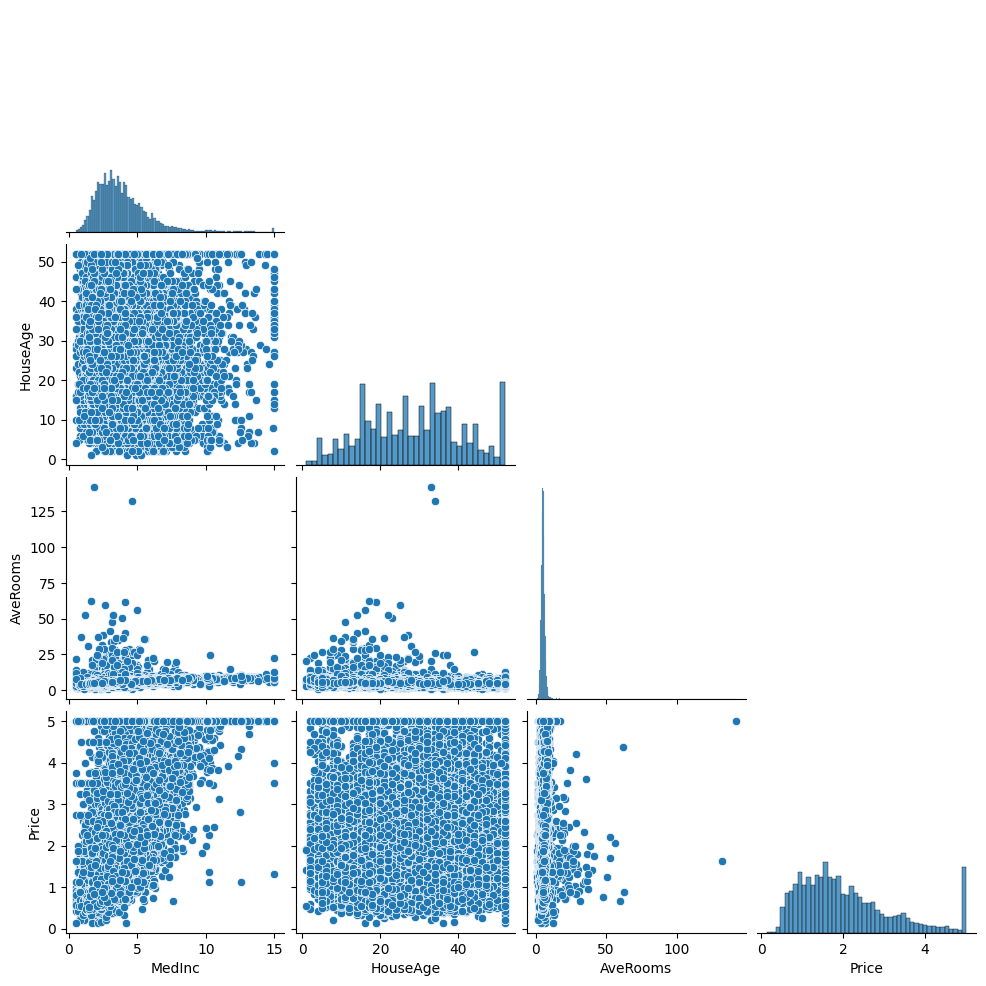

In [2]:
# --- Step 3: Data Visualization ---
plt.figure(figsize=(14, 10))

# 1. Histogram: Distribution of House Prices
plt.subplot(2, 2, 1)
sns.histplot(df['Price'], kde=True, bins=30, color='coral')
plt.title('Histogram: House Price Distribution')

# 2. Scatter Plot: Median Income vs. Price
plt.subplot(2, 2, 2)
sns.scatterplot(x='MedInc', y='Price', data=df, alpha=0.4, color='teal')
plt.title('Scatter Plot: Median Income vs Price')

# 3. Boxplot: Distribution of House Ages
plt.subplot(2, 2, 3)
sns.boxplot(x=df['HouseAge'], color='lightblue')
plt.title('Boxplot: House Age Distribution')

plt.tight_layout()
plt.show()

# 4. Pairplot: Relationships between a subset of features
# (We select a subset of columns so the plot renders quickly)
print("\n--- Pairplot (Subset of Features) ---")
subset_cols = ['MedInc', 'HouseAge', 'AveRooms', 'Price']
sns.pairplot(df[subset_cols], corner=True)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# --- Step 4: Train the Baseline Model ---

# 1. Separate features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Report Regression Metrics
print("--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

# --- Step 5: Save the Artifact ---

# Save the trained model
joblib.dump(model, 'house_price_linear_regression_model.pkl')
print("\nSuccess! Model saved as 'house_price_linear_regression_model.pkl'")

--- Model Evaluation ---
Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
R-squared Score: 0.5758

Success! Model saved as 'house_price_linear_regression_model.pkl'
